In [1]:
import scanpy as sc
import numpy as np
from csmf.utils.rank_selection_svd import rank_selection_svd_pipeline
import matplotlib.pyplot as plt
import pandas as pd
from regression.preprocessing import PseudobulkProcessor

In [2]:
our_cdata = sc.read("/data1/soldatr/luan/projects/cell_tissue_phenotype/results/our_cdata_raw_celltypes.h5ad")

In [3]:
# for our_cdata

import pandas as pd

df_covariate = pd.read_csv("/home/lel2/luan/projects/cell_tissue_phenotype/results/normal_covariates.csv")


our_cdata.obs['sample_id'] = our_cdata.obs['exp_name'].astype('string').str.cat(our_cdata.obs['indiv_id'].astype('string'), sep = '_')
our_cdata.obs['sample_id'] = our_cdata.obs['sample_id'].astype('category')

# #map age and sex
# meta = df
# age_map = meta.set_index("indiv_id")["ages"]
# sex_map = meta.set_index("indiv_id")["sexes"]

# our_cdata.obs["ages"] = our_cdata.obs["indiv_id"].map(age_map)
# our_cdata.obs["sexes"] = our_cdata.obs["indiv_id"].map(sex_map)


# #combined sexes and src into one column
# our_cdata.obs['sex_src'] = our_cdata.obs['sexes'].astype(str) + '_' + our_cdata.obs['src'].astype(str)
# our_cdata.obs['sex_src'] = our_cdata.obs['sex_src'].astype("category")


# n_samples = len(our_cdata.obs['sample_id'].cat.categories)
cell_type_list = our_cdata.obs['cell_type'].cat.categories.tolist()

correct_covariates = ["sex_src", "age"]

# extract out stem cell gene expression
sample_column = "sample_id"
celltype_column = "cell_type"
celltype_list = ["HSC_MPP"]

subset_list = [sample_column]

# for getting HSC_MPP in normal samples

# feature_filter_conditions = {celltype_column: celltype_list}

feature_filter_conditions = None
sample_filter_list = None

groupby_list = [sample_column, celltype_column]



pp = PseudobulkProcessor(adata = our_cdata,
                         covariate_csv = "/home/lel2/luan/projects/cell_tissue_phenotype/results/normal_covariates.csv",
                         out_dir = "output",
                         method = "max_counts",
                         cell_type = "HSC_MPP",
                         min_cells = 3,
                         lower_pct = 5.0,
                         upper_pct = 95.0,
                         pb_method = "sum_log",
                         scale_factor = 1e6,    
                         correct_covariates = correct_covariates, 
                         cell_type_list = cell_type_list,
                         sample_column = sample_column, 
                        )




In [4]:
# do filter 
# also obtain meta data and cell type proportion
Xs_pseudobulk = pp.build_pipeline(feature_filter_conditions, sample_filter_list, subset_list, groupby_list)
                                 

Number of genes to keep = 17573
Counts: 5.0%=751.0, 95.0%=8448.0


/data1/soldatr/luan/projects/cell_tissue_phenotype/tools/regression/src/regression/preprocessing.py:768: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_counts = self.adata.obs.groupby(groupby_list).size().unstack(fill_value=0)


In [5]:
from typing import List

def subset_adata(adata, celltype_interest: List[str] = ['HSC', 'MPP']):
    mask = adata.obs['cell_type'].isin(celltype_interest)
    return adata[mask, :].copy()

adata_sub = subset_adata(pp.adata, celltype_interest = ['HSC', 'MPP'])

In [6]:
adata_sub.obs["ages"] = pd.to_numeric(adata_sub.obs["ages"], errors='coerce').astype('float32')
# sex_src -> one-hot dummies
sex_dummies = pd.get_dummies(adata_sub.obs['sex_src'], prefix='sex_src', drop_first=True)
for col in sex_dummies.columns:
    adata_sub.obs[col] = sex_dummies[col].astype('float32')

num_cols = ['ages'] + list(sex_dummies.columns)
for col in num_cols:
    adata_sub.obs[col] = adata_sub.obs[col].astype('float32')


In [7]:
adata_sub.obs['sample_id'] = adata_sub.obs['exp_name'].astype('string').str.cat(adata_sub.obs['indiv_id'].astype('string'), sep = '_')
adata_sub.obs['sample_id'] = adata_sub.obs['sample_id'].astype('category')

In [8]:
adata_sub.obs

,exp_name,barcode,num_umis_orig,num_umis_fil,is_doublet,mito_frac,is_ultima,indiv_id,src,metacell,...,cell_type,sample_id,ages,sexes,sex_src,sex_src_female_nov_20,sex_src_female_old,sex_src_male_new,sex_src_male_nov_20,sex_src_male_old
demux_14_02_22_1_AAACCCAAGAATCGTA-1,demux_14_02_22_1,AAACCCAAGAATCGTA-1,3641.0,3376.0,False,0.040364,True,N99,new,1865,...,MPP,demux_14_02_22_1_N99,50.0,male,male_new,0.0,0.0,1.0,0.0,0.0
demux_14_02_22_1_AAACCCACACCTATCC-1,demux_14_02_22_1,AAACCCACACCTATCC-1,4228.0,3873.0,False,0.038719,True,N175,new,876,...,MPP,demux_14_02_22_1_N175,85.0,male,male_new,0.0,0.0,1.0,0.0,0.0
demux_14_02_22_1_AAACCCACAGAGAAAG-1,demux_14_02_22_1,AAACCCACAGAGAAAG-1,4094.0,3830.0,False,0.043218,True,N159,new,841,...,MPP,demux_14_02_22_1_N159,77.0,male,male_new,0.0,0.0,1.0,0.0,0.0
demux_14_02_22_1_AAACCCACAGTTGCGC-1,demux_14_02_22_1,AAACCCACAGTTGCGC-1,2944.0,2721.0,False,0.029254,True,N175,new,1611,...,HSC,demux_14_02_22_1_N175,85.0,male,male_new,0.0,0.0,1.0,0.0,0.0
demux_14_02_22_1_AAACCCAGTCGAGTGA-1,demux_14_02_22_1,AAACCCAGTCGAGTGA-1,4933.0,4605.0,False,0.057125,True,N99,new,3350,...,MPP,demux_14_02_22_1_N99,50.0,male,male_new,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
demux_11_04_21_2_TTTGGAGTCGTTCATT-1,demux_11_04_21_2,TTTGGAGTCGTTCATT-1,1349.0,1259.0,False,0.046212,False,N177,old,1613,...,HSC,demux_11_04_21_2_N177,58.0,male,male_old,0.0,0.0,0.0,0.0,1.0
demux_11_04_21_2_TTTGGTTGTAGGAGGG-1,demux_11_04_21_2,TTTGGTTGTAGGAGGG-1,2715.0,2589.0,False,0.042884,False,N184,old,2444,...,MPP,demux_11_04_21_2_N184,80.0,female,female_old,0.0,1.0,0.0,0.0,0.0
demux_11_04_21_2_TTTGTTGAGTCGGGAT-1,demux_11_04_21_2,TTTGTTGAGTCGGGAT-1,2306.0,2144.0,False,0.057996,False,N184,old,3279,...,MPP,demux_11_04_21_2_N184,80.0,female,female_old,0.0,1.0,0.0,0.0,0.0
demux_11_04_21_2_TTTGTTGGTGACCGAA-1,demux_11_04_21_2,TTTGTTGGTGACCGAA-1,2197.0,1962.0,False,0.074965,False,N177,old,2564,...,MPP,demux_11_04_21_2_N177,58.0,male,male_old,0.0,0.0,0.0,0.0,1.0


In [9]:
adata_sub.obs['sex_src'] = adata_sub.obs['sex_src'].astype('category')

In [10]:
adata_sub.obs = adata_sub.obs.rename(columns = {"Ages": "Age"})

In [11]:
adata_sub.obs = adata_sub.obs.rename(columns = {"Sexes": "Sex"})

In [12]:
adata_sub.X = adata_sub.X.tocsr()

In [13]:
adata_sub.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 167816928 stored elements and shape (133936, 17573)>

# running FOAM

In [14]:
sample_embedding = "emb"

# cell embedding
latent_dim = 10

# latent_dim = 20

# latent_dim = 100

# latent_dim = 200


# sample embedding
embedding_dim = 10

embedding_dim = 20

embedding_dim = 30

embedding_dim = 50

# embedding_dim = 100

# embedding_dim = len(adata_sub.obs['sample_id'].cat.categories)
# can't be used for ft.pl.foam_report because it exceeds number of samples
# embedding_dim = 500


In [ ]:
import fastools as ft

# running FOAM


model_FOAM = ft.nn.FOAM(adata_sub, 
                   batch_key = "sex_src",
                   sample_key = "sample_id",
                   sample_embedding = sample_embedding, # other types are emb, mlp, embrepro, deepsets
                   latent_dim = latent_dim,   
                   embedding_dim = embedding_dim,      
                   densify = False)  # convert sparse matrix into dense


In [254]:
model_FOAM.train(50000)

compiling... done

Epoch:   0%|          | 0/107 [00:00<?, ?it/s]

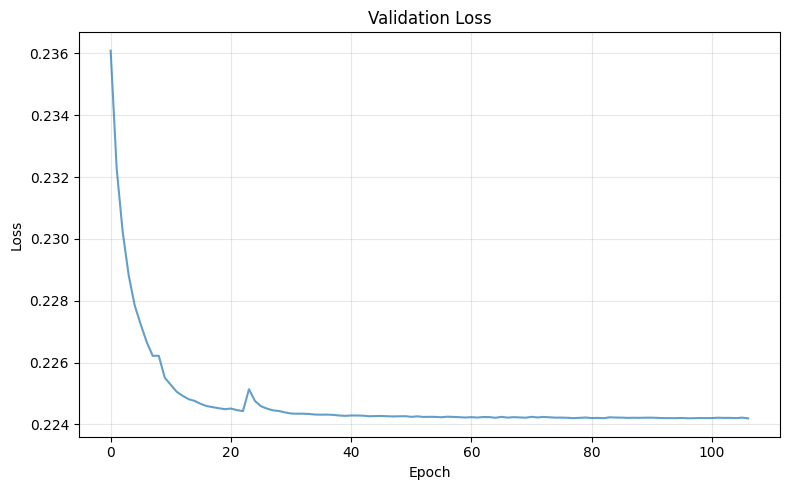

In [255]:
model_FOAM.plot_losses()

In [256]:
filepath = f"output/{sample_embedding}_{latent_dim}_{embedding_dim}_params.pkl"
# ft.nn.save_model(model_FOAM, filepath)
model_FOAM.save_params(filepath)


In [303]:
# for loading again
import fastools as ft

model_FOAM = ft.nn.FOAM(
    adata_sub,
    batch_key="sex_src",
    sample_key="sample_id",
    sample_embedding=sample_embedding,
    latent_dim=latent_dim,
    densify=False,
)

filepath = f"output/{sample_embedding}_{latent_dim}_{embedding_dim}_params.pkl"

model_FOAM.load_params(filepath)

GitInfo(path='/data1/soldatr/luan/projects/cell_tissue_phenotype/tools/fastools', commit_hash='660ad95639e8a18ef515d7ff433d6cf601640b80', clean=True)


/data1/soldatr/luan/projects/cell_tissue_phenotype/tools/fastools/fastools/nn/utils.py:1386: UserWarning: Initialization parameters mismatch:
Value for key 'embedding_dim' differs: current=10, file=100
  warnings.warn(f"Initialization parameters mismatch:\n" + "\n".join(diffs))


In [305]:
model_FOAM.latent_dim

10

In [85]:
batch_code = model_FOAM._batch_categories

In [36]:
z = model_FOAM.get_latent_representation()
gmcps = model_FOAM.get_gmcps(z[:100, :])

In [37]:
gmcps

(10, 100, 17573)

In [257]:
# can't be used for embedding_dim > min(n_samples, n_features)
ft.pl.foam_report(model_FOAM,
                 output = f"foam_report_{sample_embedding}_{latent_dim}_{embedding_dim}_params.html")

[2026-03-09 17:51:04.107] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2026-03-09 17:51:04.143] [CUML] [info] build_algo set to brute_force_knn because random_state is given


'foam_report_emb_100_100_params.html'

In [306]:
smcps = model_FOAM.get_smcps()
smcps.shape

(225, 100)

In [307]:
# for our_cdata
cell_type_proportions_df = pp.cell_type_proportions
meta = pp.meta
if "ages" in pp.meta.columns:
    meta.rename(columns={"ages": "age"}, inplace=True)


In [308]:
# do regression


from regression.estimators import RidgeRRR, RidgeRRRCV, RRRBinEvaluator
from regression.preprocessing import CompositionalILR, StandardScalerX, CenterY, TrainTestSplit
from regression.checkfitting import CheckFitting

import torch
import numpy as np
import pandas as pd
from skbio.stats.composition import closure


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ilr-transform cell type proportions
ilr_tx = CompositionalILR(zero_replacement=True).fit(cell_type_proportions_df.values)
Y_imp_ilr = ilr_tx.transform(cell_type_proportions_df.values)  # replace your earlier line

# Covariates: sex (one-hot, drop_first) and ages
Z = pd.get_dummies(meta[['sex_src']], prefix='sex_src', drop_first=True)
Z['age'] = meta['age'].astype(float)
Z = Z.astype(float)
Z.index = meta.index  # align


# stem cells of HSC_MPP and B cells
# X_design = np.concatenate([mean_gene_expr_df_HSC_MPP.values.astype(np.float64),
#                            mean_gene_expr_df_B.values.astype(np.float64),
#                            Z.to_numpy()], axis=1)

# generate bins
# train_test = TrainTestSplit(nfolds = 5, random_state = 0)

from regression.preprocessing import ImprovedTrainTestSplit

train_test = ImprovedTrainTestSplit(nfolds = 5, random_state = 0)




In [309]:
X = smcps.copy()

In [310]:
#check correlation between cell type proportion and common, shared matrices


A = cell_type_proportions_df.to_numpy()
# B = H_all.toarray()[:, :H_c_mean.shape[0]]
B = X
# B = X_c
# B = Xs_pseudobulk[sample_index, :].toarray()
X_join = np.hstack([A, B])

from scipy.stats import spearmanr
corr, pval = spearmanr(X_join, axis = 0)

#extract the cross blocks
p = A.shape[1]
corr_A_B = corr[:p, p:]

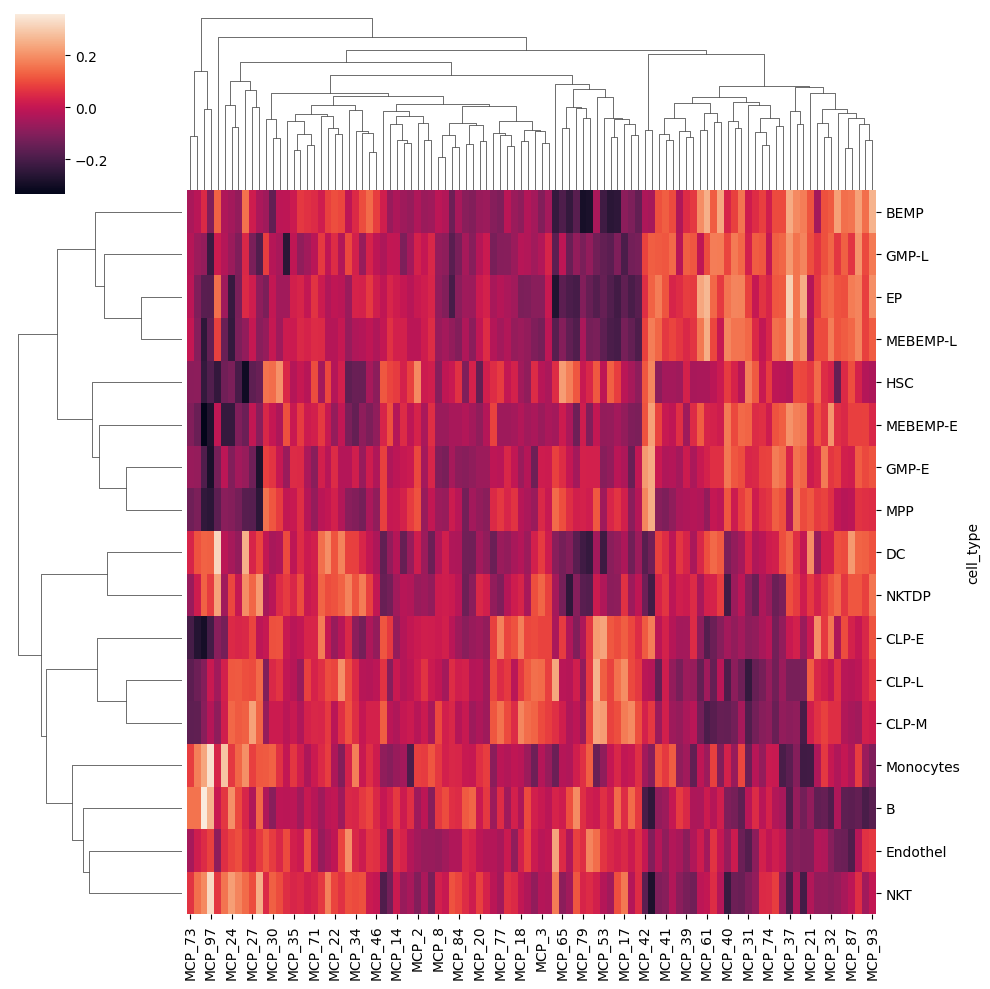

In [311]:
import seaborn as sns

corr_df = pd.DataFrame(corr_A_B,
                       index = cell_type_proportions_df.columns,
                       columns =  [f"MCP_{i}" for i in range(B.shape[1])]
                       # columns = pp.adata.var['gnames'].tolist()
                      )
# row_order = [ct for ct in celltype_order if ct in corr_df.index]

# corr_df = corr_df.reindex(row_order)
# sns.clustermap(corr_df,
              # row_cluster = False)
sns.clustermap(corr_df)

In [312]:
# stem cells of HSC_MPP
# X_design_HSC_MPP = np.concatenate([H_all.toarray(),
#                                    Z.to_numpy()], axis=1)

# X_design_HSC_MPP = H_mean.copy()
X_design_HSC_MPP = np.concatenate([X,
                                   Z.to_numpy()], axis=1)


RRRB_HSC = RRRBinEvaluator(device)
# do for nfolds
metrics_by_bin_HSC = RRRB_HSC.evaluate(X_design = X_design_HSC_MPP,
                                       Y_ilr = Y_imp_ilr, 
                                       train_test = train_test,
                                       ilr_tx = ilr_tx,
                                       cell_type_proportions_df = cell_type_proportions_df)




Bin 1: rank=10, lambda=100, MSE clr comp=0.4501
Bin 2: rank=12, lambda=100, MSE clr comp=0.3719
Bin 3: rank=12, lambda=100, MSE clr comp=0.4007
Bin 4: rank=15, lambda=100, MSE clr comp=0.4843
Bin 5: rank=12, lambda=100, MSE clr comp=0.3955


In [313]:
import numpy as np
# from collections import Counter

# Count occurrences of each unique bin value
unique_counts = np.unique(train_test.bins, return_counts=True)
print("Bin values and counts:")
for bin_val, count in zip(unique_counts[0], unique_counts[1]):
    print(f"Bin {bin_val}: {count} samples")

# # Alternative: pandas value_counts (if bins is array)
# print("\nPandas style:")
# print(pd.Series(train_test.bins).value_counts().sort_index())

# Quick check: should sum to total samples
print(f"\nTotal samples: {len(train_test.bins)}")
print(f"Sum of counts: {np.sum(unique_counts[1])}")


Bin values and counts:
Bin 1: 45 samples
Bin 2: 45 samples
Bin 3: 45 samples
Bin 4: 45 samples
Bin 5: 45 samples

Total samples: 225
Sum of counts: 225


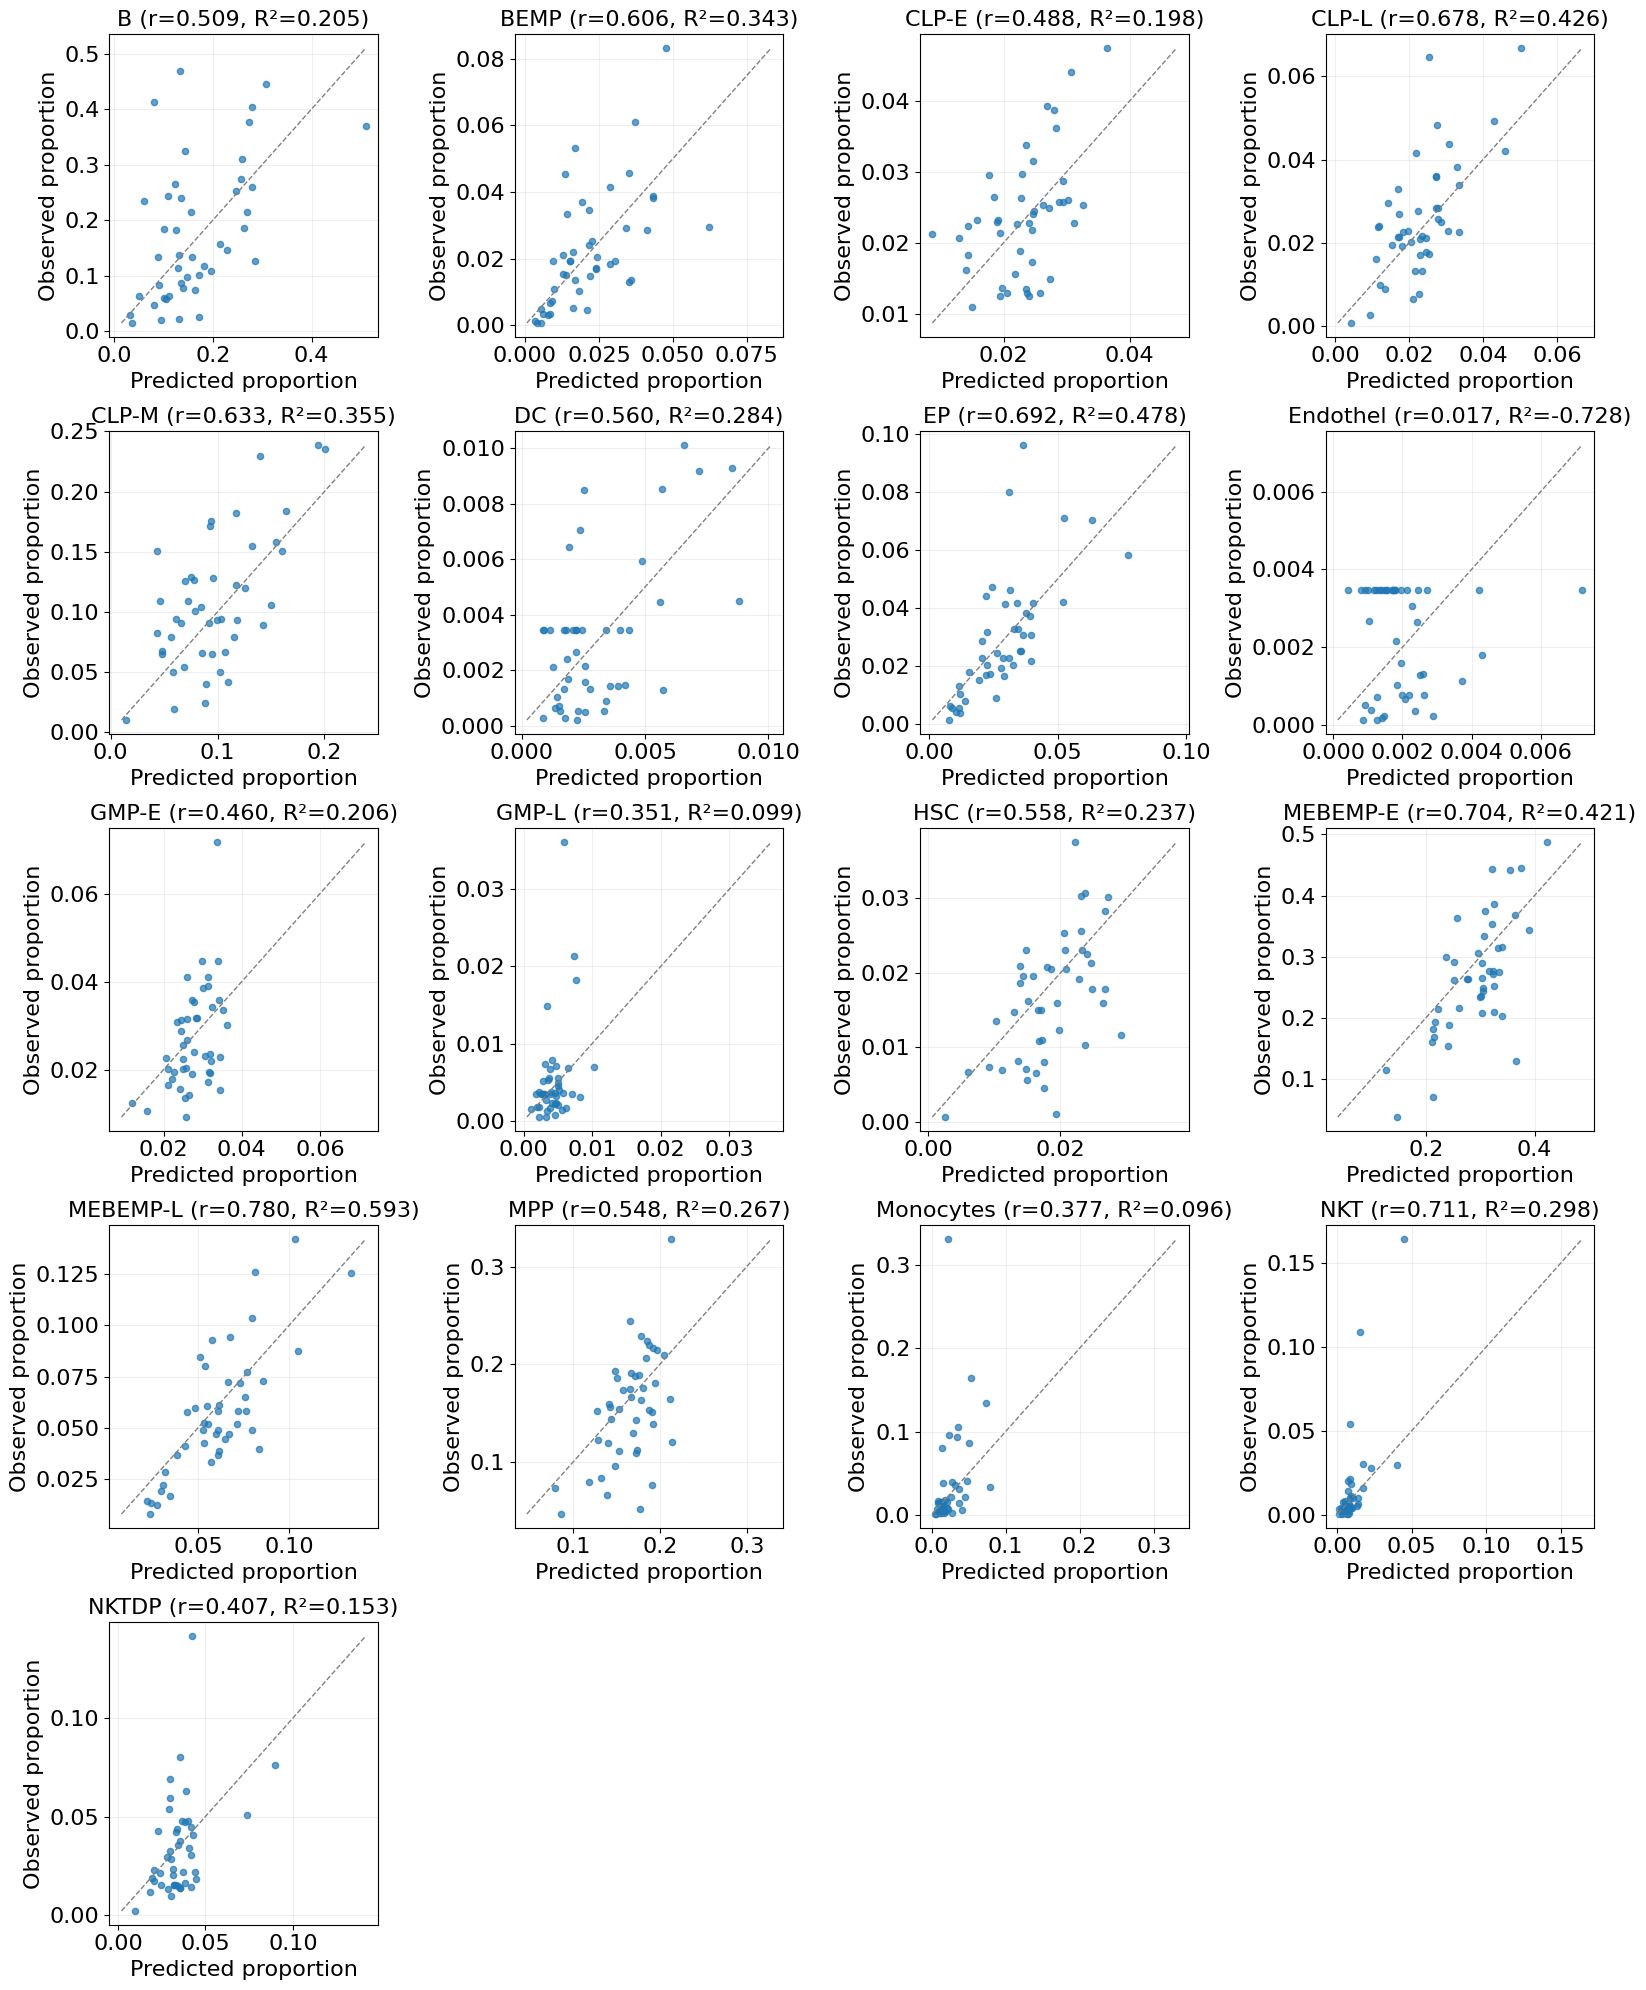

In [314]:
# Scatter grid: predicted vs observed per column, one subplot per cell type
# plot the second fold

from regression.plotting import Plotting

Plotting_HSC = Plotting()

fig, axes, metrics = Plotting_HSC.plot_test_vs_obs_grid(
    metrics_by_bin_HSC[1]["Y_test_comp_df"],
    metrics_by_bin_HSC[1]["Y_obs_comp_df"],
    ncols=4,
    title_prefix="",
    label_fontsize = 16, x_tick_labelsize = 16, y_tick_labelsize = 16, title_fontsize = 16
)
# print(metrics)

(-1.0, 1.0)

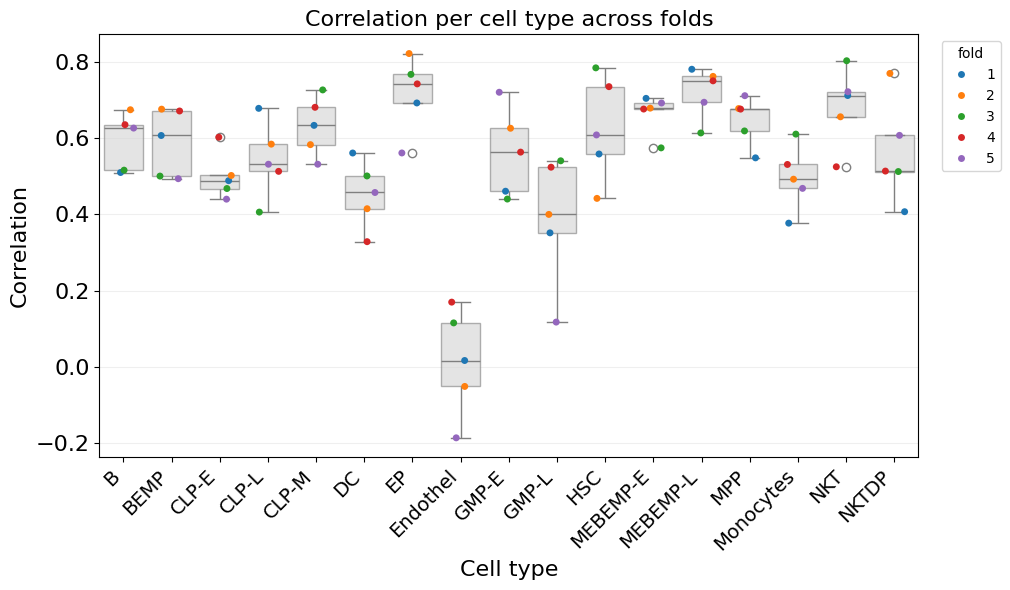

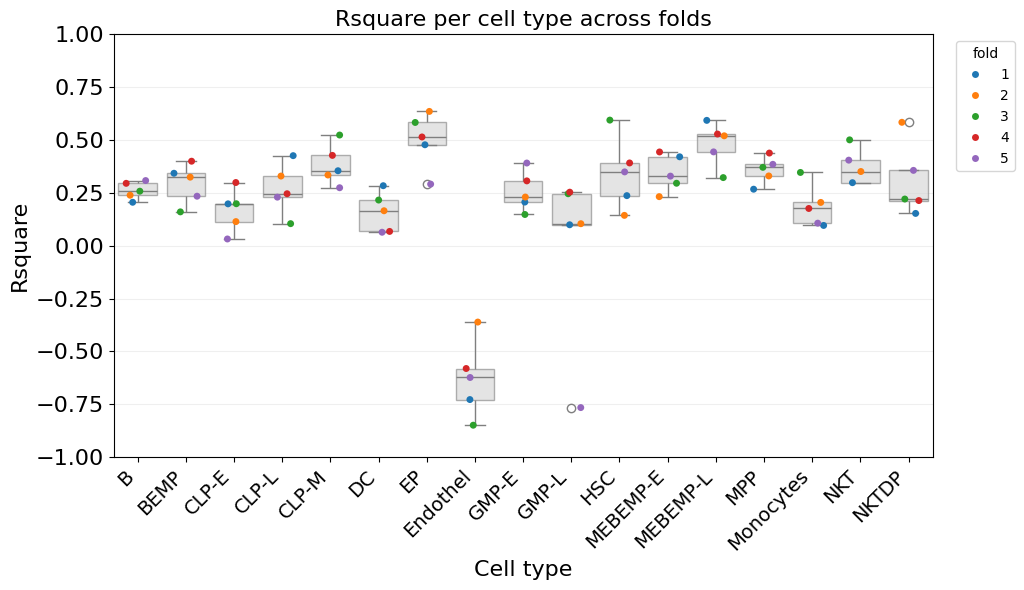

In [315]:
from regression.plotting import Plotting

Plotting_HSC = Plotting()
# Box plots with per-fold scatter for per-part metrics (corr or R^2)

fig, ax = Plotting_HSC.distribution_across_folds(metrics_by_bin_HSC, metric_name="Correlation",
                                                label_fontsize = 16, title_fontsize = 16,
                                                x_tick_labelsize = 14, y_tick_labelsize = 16)

fig, ax = Plotting_HSC.distribution_across_folds(metrics_by_bin_HSC, metric_name="Rsquare",
                                                label_fontsize = 16, title_fontsize = 16,
                                                x_tick_labelsize = 14, y_tick_labelsize = 16)
ax.set_ylim([-1, 1])

In [272]:
X_design_1_2 = np.concatenate([Xs_pseudobulk.toarray(),
                             Z.to_numpy()], axis=1)


RRRB_1_2 = RRRBinEvaluator(device)
metrics_by_bin_1_2 = RRRB_1_2.evaluate(X_design = X_design_1_2,
                                           Y_ilr = Y_imp_ilr, 
                                           train_test = train_test,
                                           ilr_tx = ilr_tx,
                                           cell_type_proportions_df = cell_type_proportions_df)


Bin 1: rank=16, lambda=562.34, MSE clr comp=0.3843
Bin 2: rank=16, lambda=1000, MSE clr comp=0.3928
Bin 3: rank=16, lambda=1000, MSE clr comp=0.3652
Bin 4: rank=16, lambda=562.34, MSE clr comp=0.4402
Bin 5: rank=16, lambda=1000, MSE clr comp=0.4278


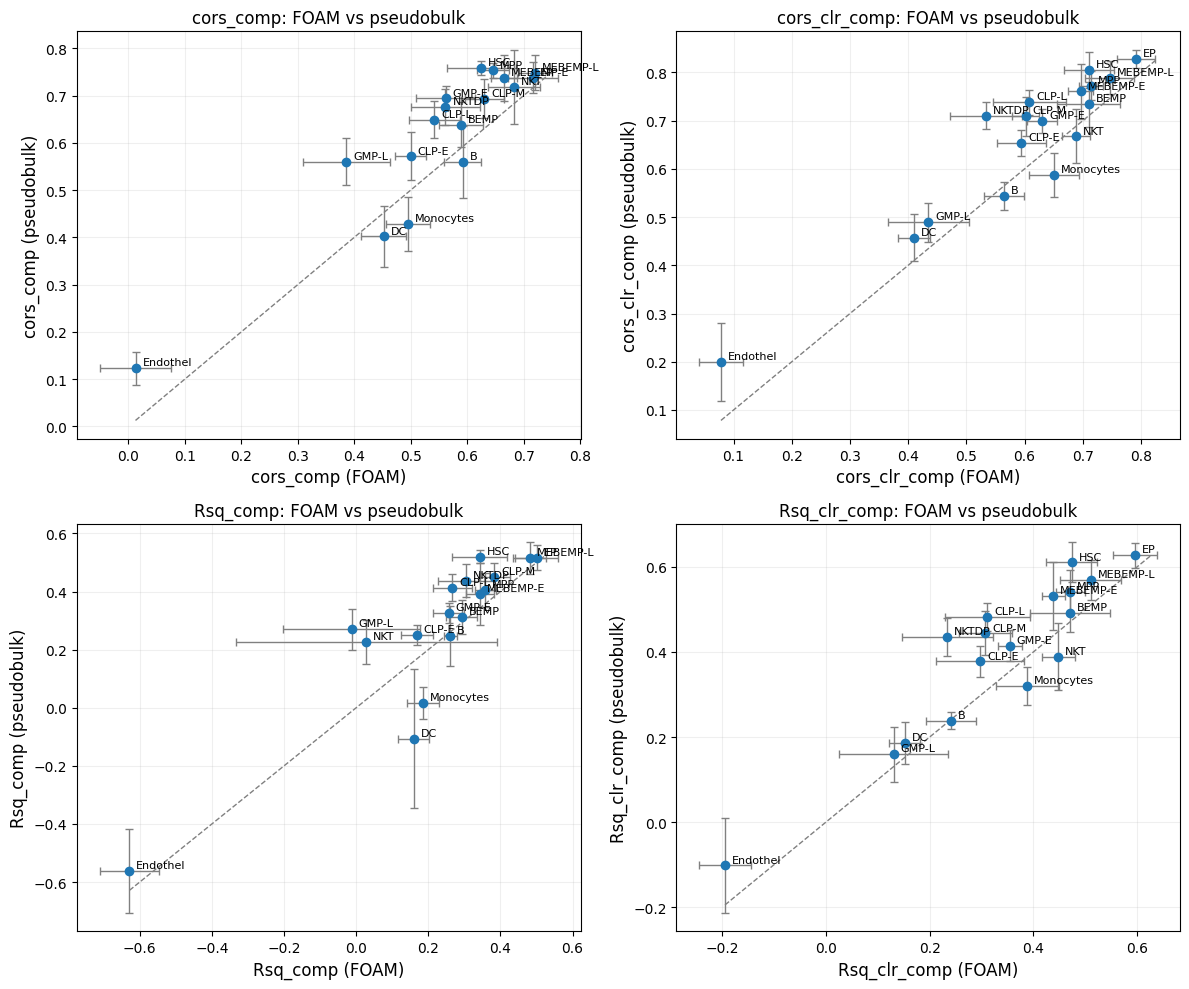

In [316]:
Plotting_HSC = Plotting()

cell_type_1 = "FOAM"
cell_type_1_2 = "pseudobulk"

# Assuming you have an instance `plotter = Plotting()`
metric_name_list = ["cors_comp", "cors_clr_comp", "Rsq_comp", "Rsq_clr_comp"]


fig, axes = Plotting_HSC.scatter_two_celltypes_panel(
    celltype_x=cell_type_1,
    metrics_by_bin_x=metrics_by_bin_HSC,
    celltype_y=cell_type_1_2,
    metrics_by_bin_y=metrics_by_bin_1_2,
    metric_names=metric_name_list,
    ncols=2
)


In [279]:

adata_sub.obs['cell_type_combined'] =  adata_sub.obs['cell_type'].replace({'HSC': 'HSC_MPP', 'MPP': 'HSC_MPP'})
adata_sub.obs['cell_type_combined'] = adata_sub.obs['cell_type_combined'].astype('category')


In [317]:
pblk = model_FOAM.get_pseudobulk(adata_sub, 
                                 cell_type = "HSC_MPP",
                                 cell_type_key = "cell_type_combined",
                                 sample_key = "sample_id",
                                 sample_threshold_cells=1
                                 )
mcp_pblk = pblk.obsm["MCP"]

In [318]:
mcp_pblk.shape

(225, 100)

In [319]:
X_design_FOAM_pblk = np.concatenate([mcp_pblk,
                             Z.to_numpy()], axis=1)


RRRB_FOAM_pblk = RRRBinEvaluator(device)
metrics_by_bin_FOAM_pblk = RRRB_FOAM_pblk.evaluate(X_design = X_design_FOAM_pblk,
                                           Y_ilr = Y_imp_ilr, 
                                           train_test = train_test,
                                           ilr_tx = ilr_tx,
                                           cell_type_proportions_df = cell_type_proportions_df)


Bin 1: rank=10, lambda=100, MSE clr comp=0.4501
Bin 2: rank=12, lambda=100, MSE clr comp=0.3719
Bin 3: rank=12, lambda=100, MSE clr comp=0.4007
Bin 4: rank=15, lambda=100, MSE clr comp=0.4843
Bin 5: rank=12, lambda=100, MSE clr comp=0.3955


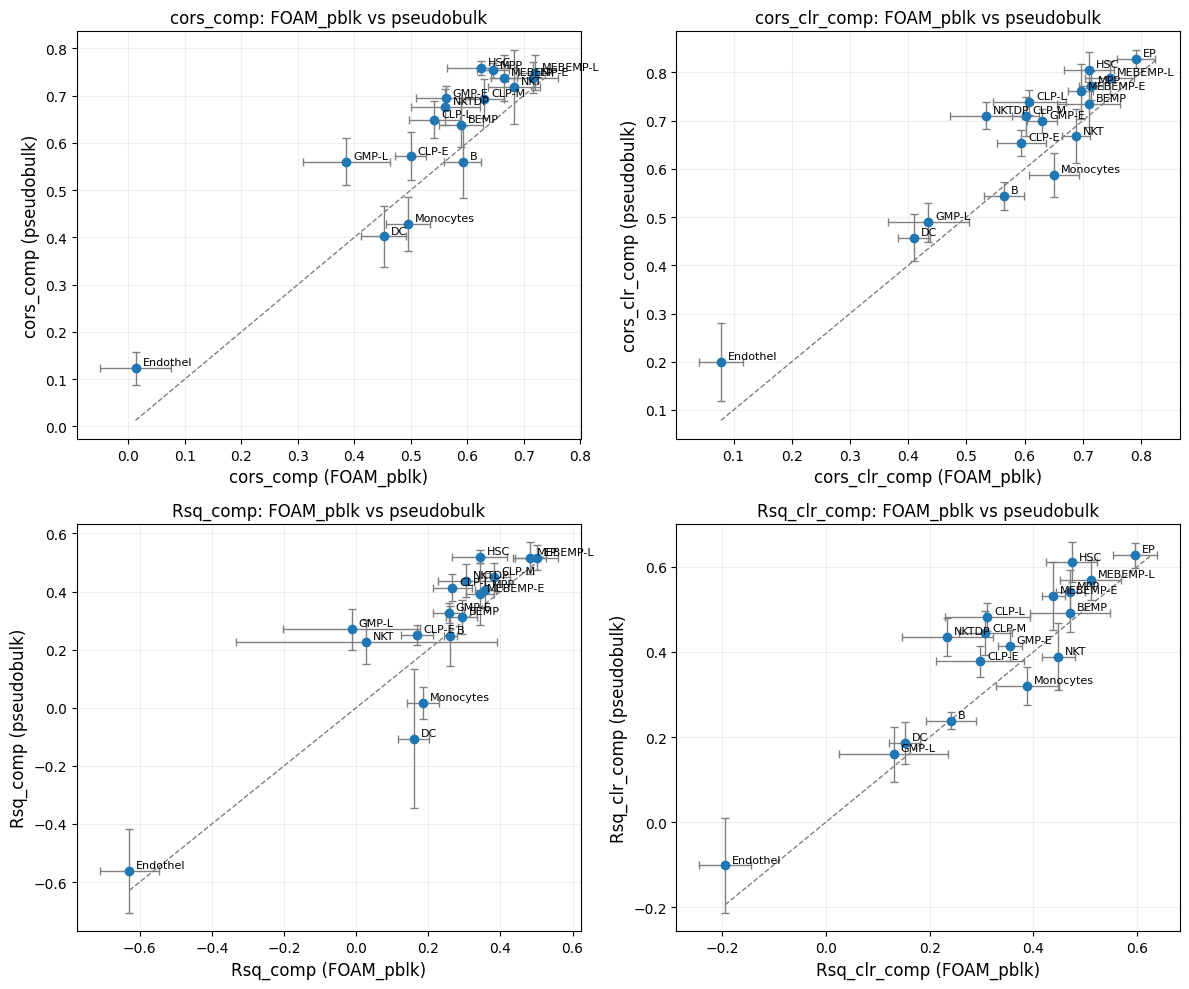

In [320]:
Plotting_HSC = Plotting()

cell_type_1 = "FOAM_pblk"
cell_type_1_2 = "pseudobulk"

# Assuming you have an instance `plotter = Plotting()`
metric_name_list = ["cors_comp", "cors_clr_comp", "Rsq_comp", "Rsq_clr_comp"]


fig, axes = Plotting_HSC.scatter_two_celltypes_panel(
    celltype_x=cell_type_1,
    metrics_by_bin_x=metrics_by_bin_FOAM_pblk,
    celltype_y=cell_type_1_2,
    metrics_by_bin_y=metrics_by_bin_1_2,
    metric_names=metric_name_list,
    ncols=2
)


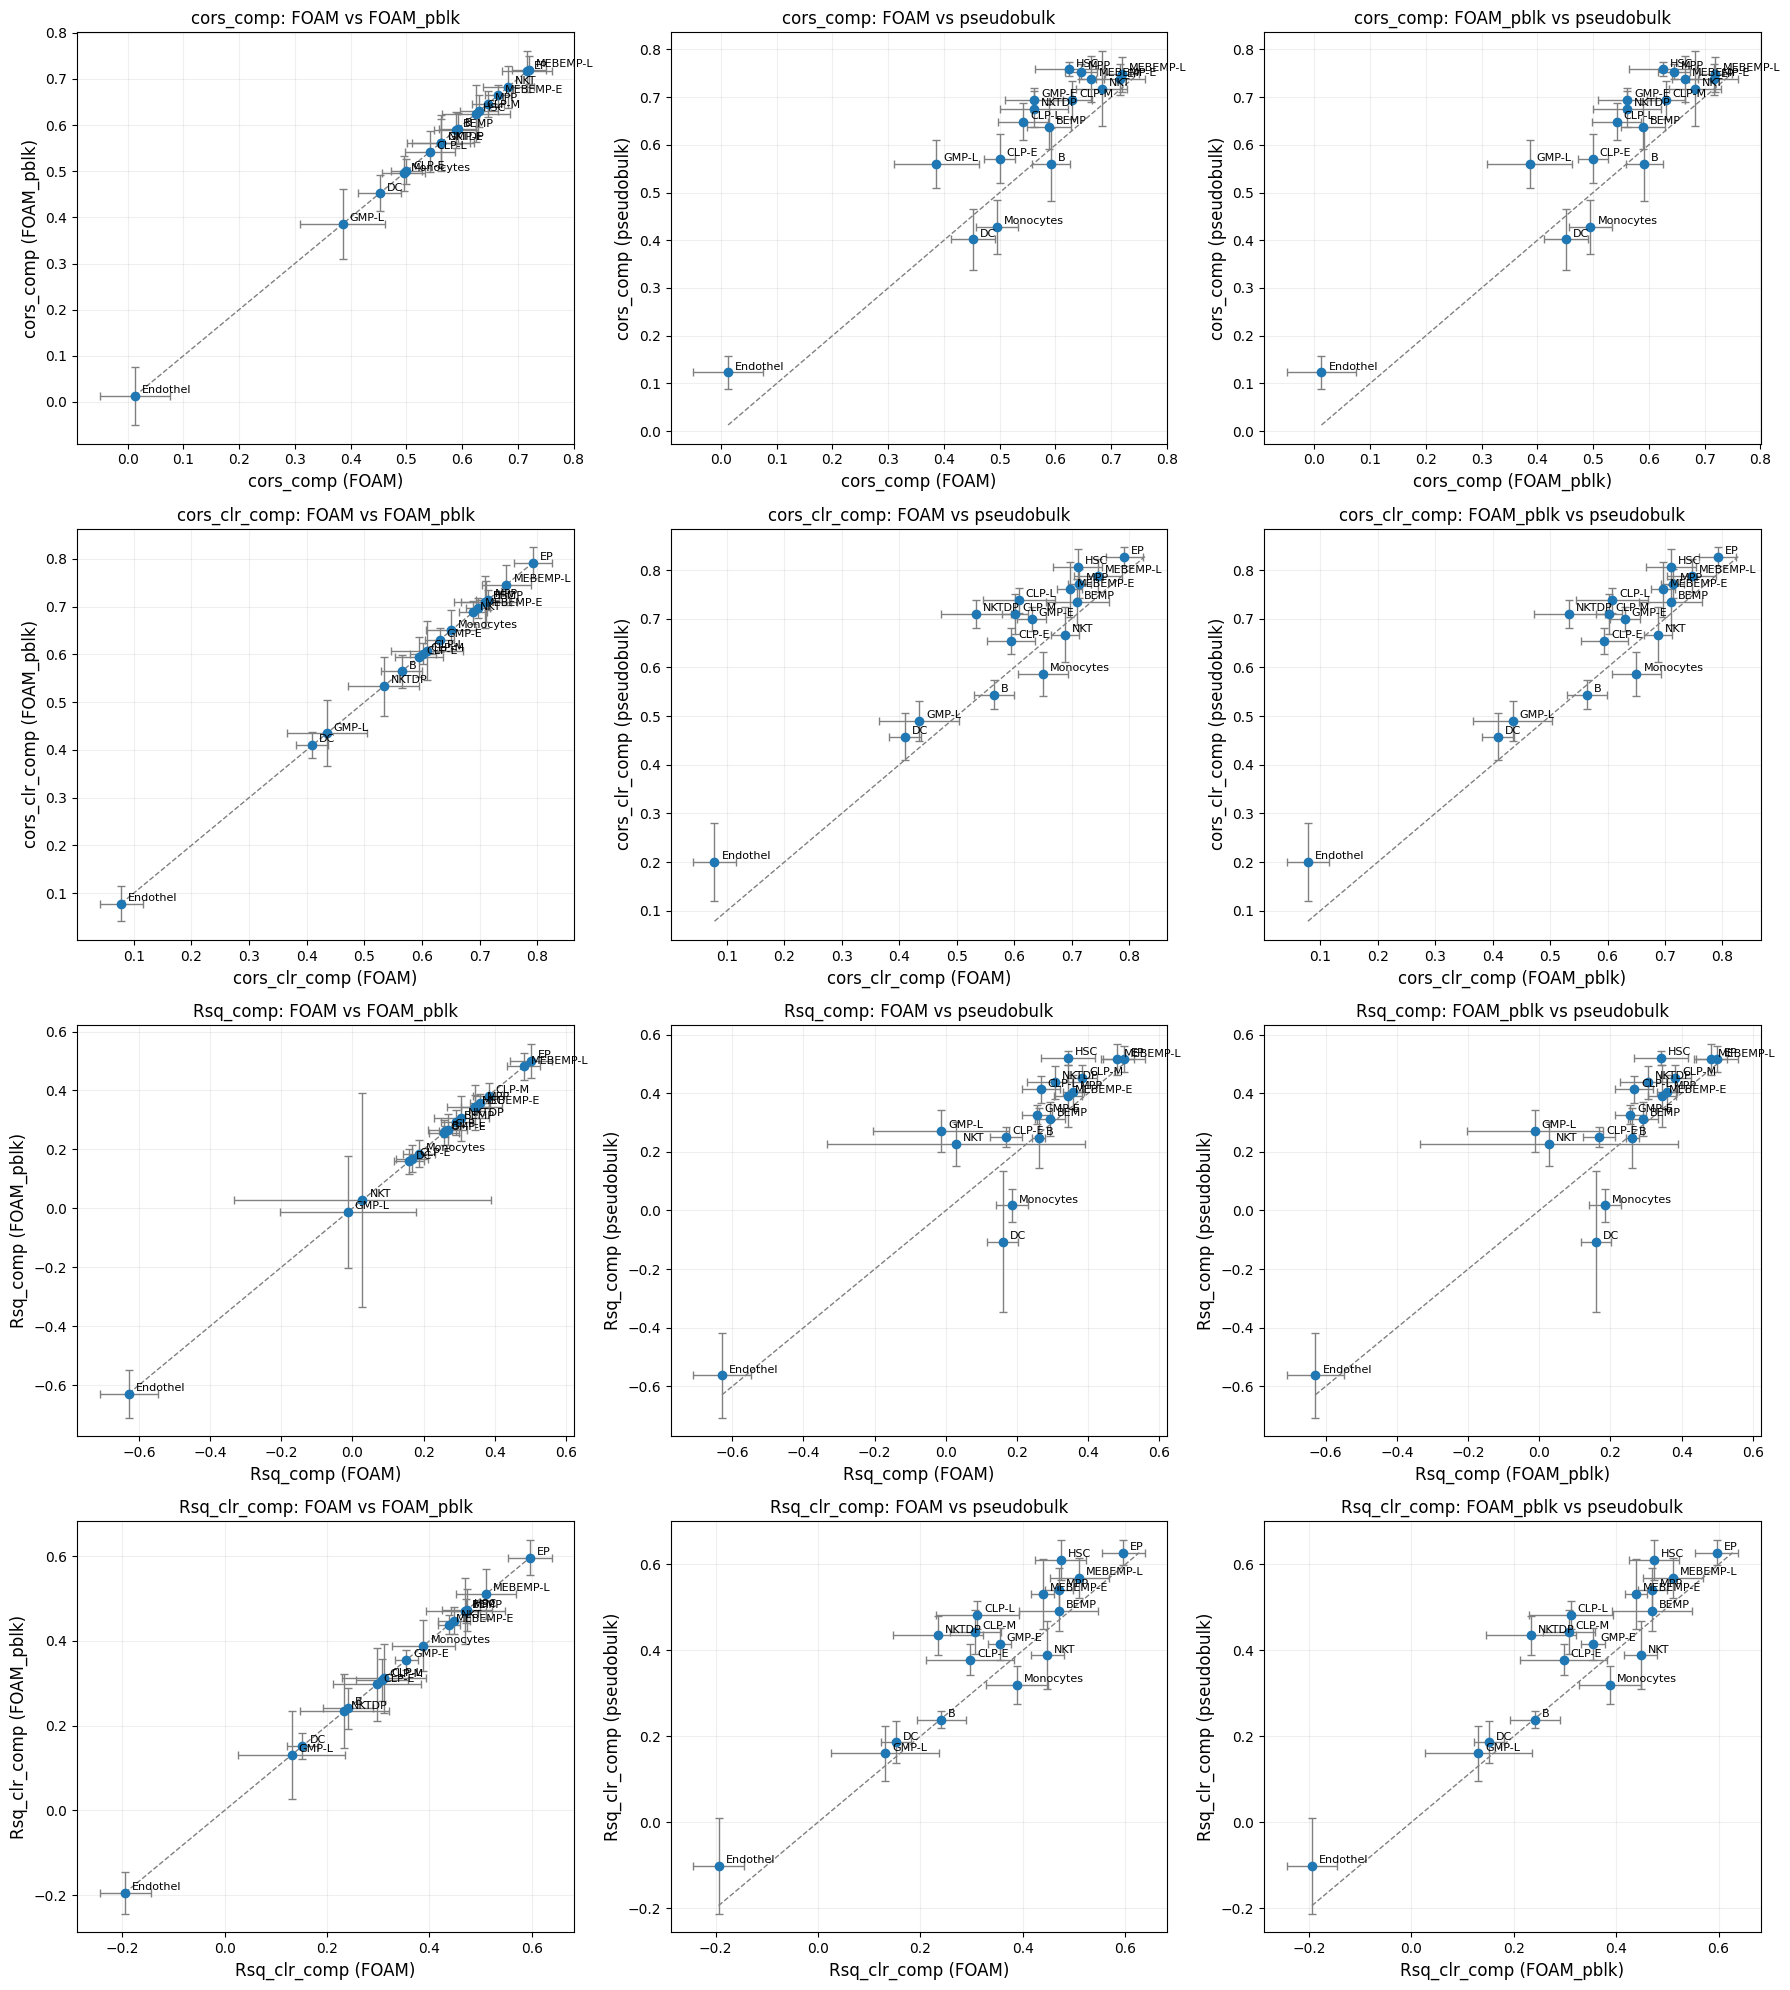

In [321]:
Plotting_compare = Plotting()

# Assuming you have an instance `plotter = Plotting()`
metric_name_list = ["cors_comp", "cors_clr_comp", "Rsq_comp", "Rsq_clr_comp"]

cell_type_1 = "FOAM"
cell_type_2 = "FOAM_pblk"
cell_type_1_2 = "pseudobulk"

metrics_dict = {cell_type_1: metrics_by_bin_HSC, 
                cell_type_2: metrics_by_bin_FOAM_pblk, 
                cell_type_1_2: metrics_by_bin_1_2}


fig, axes = Plotting_compare.scatter_design_matrices(metrics_dict = metrics_dict, metric_names = metric_name_list)
